Import Packages 

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline
%config InlineBackend.figure_format="retina"
import numpy as np
from PIL import Image
import pickle
import os
import cv2
import random
import time
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
import math
from IPython import display
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torch.functional as F
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import TensorDataset
import pdb
import ast

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"you are using {device}")

you are using cuda:0


In [2]:
base_color_tags = ["red", "orange", "yellow", "Tangerine", "dark", "black", "lavender", "lav", "brown", "copper", "cream", "white", "creamy", "olive", "red base", "halloween"]  #"axanthic"
base_color_labels = ["red", "yellow", "dark", "lavender", "cream", "olive"]

We want to sort the raw tags from scraping, the ones listed in `base_color_tags` to fit the tags we want to classify into: `base_color_labels`. For this `dark` covers `black`, `brown`; `red` covers `copper`; `lavender` covers `lav`; and `cream` covers `creamy` and `white`. 

Load dataset

In [3]:
gecko_traits = pd.read_csv("trait-image.csv")

# Clean data up a bit
index = 0
for item in gecko_traits["Tag"]:
    item = ast.literal_eval(item) # convert sting to list
    new_item = []
    for tag in item:
        tag = tag.lower() # convert to lowercase
        new_item.append(tag)
    gecko_traits.loc[index, "Tag"] = new_item
    index += 1

gecko_traits.to_csv("gecko_by_traits.csv")  
gecko_traits

,Tag,Image Name
0,[phantom],2123697.jpeg
1,"[pinstripe, dark]",2702167.jpeg
2,"[dalmatian, super dalmatian, ink spot, red spo...",2702191.jpeg
3,[buckskin],2571629.jpeg
4,"[dalmatian, harlequin, yellow]",2077235.jpeg
...,...,...
5920,"[pin-dashed, red base]",1616388.jpeg
5921,[harlequin],2398217.jpeg
5922,"[brindle, dalmatian]",2673233.jpeg
5923,"[flame, tri-color]",2662688.jpeg


### Data-Cleaning & Preprocessing

To Train the base color classification part of the model, we need to make a dataset that tags them by color:

In [4]:
new = []

for index, row in gecko_traits.iterrows():
    tags = row["Tag"]
    image_name = row["Image Name"]
    color = []
    traits = []
    addit = False

    for tag in tags:
        if tag in base_color_tags: # get base color traits
            color.append(tag)
            addit = True
        else: # get pattern traits
            traits.append(tag)

    if addit: # add to new dataframe for base color training
        new.append({"Color": color, "Traits": traits, "Image Name": image_name})

geckos_by_color = pd.DataFrame(new)
geckos_by_color

,Color,Traits,Image Name
0,[dark],[pinstripe],2702167.jpeg
1,[red],"[dalmatian, super dalmatian, ink spot, red spot]",2702191.jpeg
2,[yellow],"[dalmatian, harlequin]",2077235.jpeg
3,"[cream, black, dark]",[extreme harlequin],1563067.jpeg
4,[red],[harlequin],2702154.jpeg
...,...,...,...
3182,[orange],"[brindle, harlequin, portholes]",1967252.jpeg
3183,"[cream, yellow]",[harlequin],1880987.jpeg
3184,[red],"[dalmatian, portholes, bi-color]",1880952.jpeg
3185,[red base],[pin-dashed],1616388.jpeg


Normalize Color labels as described above. 

In [5]:
redundants = ["black", "lav", "brown", "orange", "copper", "white", "creamy", "red base", "halloween", "Tangerine"]
index = 0

for item in geckos_by_color["Color"]:
    tags_ind = 0
    tags = geckos_by_color.loc[index, "Color"]
    for tag in item:
        if tag in redundants:
            if tag in ["black", "brown", "halloween"]:
                tags[tags_ind] = "dark"
            elif tag in ["lav"]:
                tags[tags_ind] = "lavender"
            elif tag in ["copper", "orange", "red base", "tangerine"]:
                tags[tags_ind] = "red"
            elif tag in ["white", "creamy"]:
                tags[tags_ind] = "cream"
        tags_ind += 1
    geckos_by_color.loc[index, "Color"] = list(np.unique(np.array(tags)))
    index += 1


geckos_by_color.to_csv("gecko_by_color.csv")
geckos_by_color

,Color,Traits,Image Name
0,[dark],[pinstripe],2702167.jpeg
1,[red],"[dalmatian, super dalmatian, ink spot, red spot]",2702191.jpeg
2,[yellow],"[dalmatian, harlequin]",2077235.jpeg
3,"[cream, dark]",[extreme harlequin],1563067.jpeg
4,[red],[harlequin],2702154.jpeg
...,...,...,...
3182,[red],"[brindle, harlequin, portholes]",1967252.jpeg
3183,"[cream, yellow]",[harlequin],1880987.jpeg
3184,[red],"[dalmatian, portholes, bi-color]",1880952.jpeg
3185,[red],[pin-dashed],1616388.jpeg


Translate to one-hot encoding

In [6]:
color_lists = geckos_by_color.explode("Color")
one_hotted = pd.get_dummies(color_lists, columns=["Color"], prefix='', prefix_sep='')
one_hot_color = one_hotted.groupby(level=0).sum()
one_hot_color["Image Name"] = geckos_by_color["Image Name"].values

one_hot_color.to_csv("gecko_by_color_onehot.csv")
one_hot_color

,Traits,Image Name,cream,dark,lavender,olive,red,yellow
0,[pinstripe],2702167.jpeg,0,1,0,0,0,0
1,"[dalmatian, super dalmatian, ink spot, red spot]",2702191.jpeg,0,0,0,0,1,0
2,"[dalmatian, harlequin]",2077235.jpeg,0,0,0,0,0,1
3,"[extreme harlequin, extreme harlequin]",1563067.jpeg,1,1,0,0,0,0
4,[harlequin],2702154.jpeg,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...
3182,"[brindle, harlequin, portholes]",1967252.jpeg,0,0,0,0,1,0
3183,"[harlequin, harlequin]",1880987.jpeg,1,0,0,0,0,1
3184,"[dalmatian, portholes, bi-color]",1880952.jpeg,0,0,0,0,1,0
3185,[pin-dashed],1616388.jpeg,0,0,0,0,1,0


Create distribution dataset as well, another form of data representation where if we have a gecko with cream: 1 and red: 1, we turn that into cream: 0.5 and red: 0.5 instead.

In [7]:
new = []
multis = 0
for index, row in one_hot_color.iterrows():
    colors_raw = np.array(row[2:])
    denom = np.sum(colors_raw)
    colors = colors_raw / denom
    if denom > 1:
        multis += 1
        #print(f"hey : {denom}")
    colors_raw /= 1
    #print(colors)
    new.append({"Image Name": row["Image Name"], 
                "Cream": colors[0], 
                "Dark": colors[1],
                "Lavender": colors[2],
                "Olive": colors[3],
                "Red": colors[4],
                "Yellow": colors[5],
                "Colors Raw": list(colors),
                "Colors Hot": list(colors_raw),
                "Traits": row["Traits"]
                })
    
distr_color = pd.DataFrame(new)

distr_color.to_csv("gecko_by_color_distr.csv")

def drop_rows(dataframe, image_names):
    return dataframe[~dataframe['Image Name'].isin(image_names)]

image_names_to_drop = ['2398217.jpeg', '2662688.jpeg', '2673233.jpeg', '2523692.jpeg']

distr_color = drop_rows(distr_color, image_names_to_drop)
print(multis)

distr_color

505


,Image Name,Cream,Dark,Lavender,Olive,Red,Yellow,Colors Raw,Colors Hot,Traits
0,2702167.jpeg,0.0,1.0,0.0,0.0,0.0,0.0,"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0]",[pinstripe]
1,2702191.jpeg,0.0,0.0,0.0,0.0,1.0,0.0,"[0.0, 0.0, 0.0, 0.0, 1.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 1.0, 0.0]","[dalmatian, super dalmatian, ink spot, red spot]"
2,2077235.jpeg,0.0,0.0,0.0,0.0,0.0,1.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0]","[dalmatian, harlequin]"
3,1563067.jpeg,0.5,0.5,0.0,0.0,0.0,0.0,"[0.5, 0.5, 0.0, 0.0, 0.0, 0.0]","[1.0, 1.0, 0.0, 0.0, 0.0, 0.0]","[extreme harlequin, extreme harlequin]"
4,2702154.jpeg,0.0,0.0,0.0,0.0,1.0,0.0,"[0.0, 0.0, 0.0, 0.0, 1.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 1.0, 0.0]",[harlequin]
...,...,...,...,...,...,...,...,...,...,...
3181,2083303.jpeg,0.0,0.5,0.0,0.0,0.5,0.0,"[0.0, 0.5, 0.0, 0.0, 0.5, 0.0]","[0.0, 1.0, 0.0, 0.0, 1.0, 0.0]","[partial pinstripe, partial pinstripe]"
3182,1967252.jpeg,0.0,0.0,0.0,0.0,1.0,0.0,"[0.0, 0.0, 0.0, 0.0, 1.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 1.0, 0.0]","[brindle, harlequin, portholes]"
3183,1880987.jpeg,0.5,0.0,0.0,0.0,0.0,0.5,"[0.5, 0.0, 0.0, 0.0, 0.0, 0.5]","[1.0, 0.0, 0.0, 0.0, 0.0, 1.0]","[harlequin, harlequin]"
3184,1880952.jpeg,0.0,0.0,0.0,0.0,1.0,0.0,"[0.0, 0.0, 0.0, 0.0, 1.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 1.0, 0.0]","[dalmatian, portholes, bi-color]"


Method 1 for equalizing class labels in dataset, this should help with equal predictions

In [8]:
target = 20000 - len(distr_color)

def count_non_zero(items):
    return sum(1 for item in items if item > 0)

multi_df = distr_color[distr_color["Colors Hot"].apply(count_non_zero) > 1]
mask_crm = distr_color["Cream"] == 1
cream_df = distr_color[mask_crm]
mask_drk = distr_color["Dark"] == 1
dark_df = distr_color[mask_drk]
mask_lav = distr_color["Lavender"] == 1
lav_df = distr_color[mask_lav]
mask_olv = distr_color["Olive"] == 1
olive_df = distr_color[mask_olv]
mask_red = distr_color["Red"] == 1
red_df = distr_color[mask_red]
mask_yel = distr_color["Yellow"] == 1
yellow_df = distr_color[mask_yel]

print(len(cream_df), len(dark_df), len(lav_df), len(olive_df), len(red_df), len(yellow_df), len(multi_df))

targets = 10000 // 7

def equalize_frame(dataframe, targets):
    iter = targets // len(dataframe)
    leftover = targets % len(dataframe)
    print(iter, leftover)
    df_copy = dataframe.copy()
    for i in range(iter - 1):
        dataframe = pd.concat([dataframe, df_copy])
    if leftover > 0:
        dataframe = pd.concat([dataframe, df_copy.head(leftover)])
    return dataframe

cream_df = equalize_frame(cream_df, targets) #+ 105)
dark_df = equalize_frame(dark_df, targets) #+ 320)
lav_df = equalize_frame(lav_df, targets) #+ 1124)
olive_df = equalize_frame(olive_df, targets) #+ 1520)
red_df = equalize_frame(red_df, targets) # + 418)
yellow_df = equalize_frame(yellow_df, targets) #+ 948)
multi_df = equalize_frame(multi_df, 5000)

print(len(cream_df), len(dark_df), len(lav_df), len(olive_df), len(red_df), len(yellow_df)), #len(multi_df))

df_cleaned = pd.concat([cream_df, dark_df, lav_df, olive_df, red_df, yellow_df]) #, #multi_df])
presence = [df_cleaned["Cream"].sum(), df_cleaned["Dark"].sum(), df_cleaned["Lavender"].sum(), df_cleaned["Olive"].sum(), df_cleaned["Red"].sum(), df_cleaned["Yellow"].sum()]
print(presence)

presence = [distr_color["Cream"].sum(), distr_color["Dark"].sum(), distr_color["Lavender"].sum(), distr_color["Olive"].sum(), distr_color["Red"].sum(), distr_color["Yellow"].sum()]
print(presence)

print(len(df_cleaned))

192 660 231 23 1019 556 505
7 84
2 108
6 42
62 2
1 409
2 316
9 455
1428 1428 1428 1428 1428 1428
[1428.0, 1428.0, 1428.0, 1428.0, 1428.0, 1428.0]
[339.8666666666667, 786.8666666666667, 276.3666666666667, 28.333333333333332, 1135.6999999999998, 618.8666666666667]
8568


Method 2 for equalizing class presence in data

In [9]:


target = 10000 - len(distr_color)
print(f"target: {target}")
presence = [distr_color["Cream"].sum(), distr_color["Dark"].sum(), distr_color["Lavender"].sum(), distr_color["Olive"].sum(), distr_color["Red"].sum(), distr_color["Yellow"].sum()]
print(presence)

mask_crm = distr_color["Cream"] == 1
cream_df = distr_color[mask_crm]
mask_drk = distr_color["Dark"] == 1
dark_df = distr_color[mask_drk]
mask_lav = distr_color["Lavender"] == 1
lav_df = distr_color[mask_lav]
mask_olv = distr_color["Olive"] == 1
olive_df = distr_color[mask_olv]
mask_red = distr_color["Red"] == 1
red_df = distr_color[mask_red]
mask_yel = distr_color["Yellow"] == 1
yellow_df = distr_color[mask_yel]

mask_olp = mask_crm | mask_drk | mask_lav | mask_olv | mask_red | mask_yel
overlap_df = distr_color[mask_olp]

#print(cream_df)




print(multis)
print(len(cream_df)+len(dark_df)+len(lav_df)+len(olive_df)+len(red_df)+len(yellow_df)+multis)
#print(len(overlap_df) == len(distr_color))
#print(len(overlap_df))

num_cream = (len(cream_df) / len(distr_color) * 10000)
num_dark = (len(dark_df) / len(distr_color) * 10000)
num_lavender = (len(lav_df) / len(distr_color) * 10000)
num_olive = (len(olive_df) / len(distr_color) * 10000)
num_red = (len(red_df) / len(distr_color) * 10000)
num_yellow = (len(yellow_df) / len(distr_color) * 10000)

targ = 10000 // 6 

new_cream_df = cream_df
length = len(cream_df)
for i in range(int(targ // num_cream) * 4 + 1):
    if i >= 0:
        cream_df = pd.concat([cream_df, new_cream_df])

new_dark_df = dark_df
length = len(dark_df)
for i in range(int(targ // num_dark) + 1):
    if i >= 0:
        dark_df = pd.concat([dark_df, new_dark_df])

new_lav_df = lav_df
length = len(lav_df)
for i in range(int(targ // num_lavender) * 4):
    if i >= 0:
        lav_df = pd.concat([lav_df, new_lav_df])

new_olive_df = olive_df
length = len(olive_df)
for i in range(int(targ // num_olive) * 4):
    if i >= 0:
        olive_df = pd.concat([olive_df, new_olive_df])

new_red_df = red_df
length = len(red_df)
for i in range(int(targ // num_red) * 2):
    if i > 0: 
        red_df = pd.concat([red_df, new_red_df])

new_yellow_df = yellow_df
length = len(yellow_df)
for i in range(int(targ // num_yellow) + 2):
    if i >= 0:
        yellow_df = pd.concat([yellow_df, new_yellow_df])

print(len(cream_df))
print(len(dark_df))
print(len(lav_df))
print(len(olive_df))
print(len(red_df))
print(len(yellow_df))


"""for i in range num_cream / len(cream_df):
    cream_df = pd.concat([cream_df, cream_df])"""

print(f"num_cream: {num_cream}")

df_cleaned_2 = pd.concat([cream_df, dark_df, lav_df, olive_df, red_df, yellow_df, overlap_df])
print(len(df_cleaned_2))
presence = [df_cleaned_2["Cream"].sum(), df_cleaned_2["Dark"].sum(), df_cleaned_2["Lavender"].sum(), df_cleaned_2["Olive"].sum(), df_cleaned_2["Red"].sum(), df_cleaned_2["Yellow"].sum()]
print(presence)

target: 6814
[339.8666666666667, 786.8666666666667, 276.3666666666667, 28.333333333333332, 1135.6999999999998, 618.8666666666667]
505
3186
1920
1320
2079
2139
1019
1668
num_cream: 602.6365348399246
12826
[2112.0, 1980.0, 2310.0, 2162.0, 2038.0, 2224.0]


Pad dataset with blanks and copies to push model away from always predicting true

In [10]:
itters = 1
for i in range(itters):
    df_cleaned= pd.concat([df_cleaned, df_cleaned], ignore_index=True)
df_cleaned 

,Image Name,Cream,Dark,Lavender,Olive,Red,Yellow,Colors Raw,Colors Hot,Traits
0,2036670.jpeg,1.0,0.0,0.0,0.0,0.0,0.0,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[fringing, kneecaps]"
1,2036567.jpeg,1.0,0.0,0.0,0.0,0.0,0.0,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[dalmatian, ink spot]"
2,2036535.jpeg,1.0,0.0,0.0,0.0,0.0,0.0,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[extreme harlequin, pinstripe, tri-color]"
3,2642936.jpeg,1.0,0.0,0.0,0.0,0.0,0.0,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[extreme harlequin, snowflake, drippy]"
4,1876812.jpeg,1.0,0.0,0.0,0.0,0.0,0.0,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[super dalmatian, ink spot]"
...,...,...,...,...,...,...,...,...,...,...
17131,2294151.jpeg,0.0,0.0,0.0,0.0,0.0,1.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0]",[tri-color]
17132,2491938.jpeg,0.0,0.0,0.0,0.0,0.0,1.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0]","[dalmatian, super dalmatian, ink spot]"
17133,2294127.jpeg,0.0,0.0,0.0,0.0,0.0,1.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0]",[tri-color]
17134,2293996.jpeg,0.0,0.0,0.0,0.0,0.0,1.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0]","[harlequin, fringing, kneecaps]"


In [11]:
#distr_color.loc[distr_color["Image Name"] == "2523692.jpeg"]
df_cleaned.loc[df_cleaned["Image Name"] == "2523692.jpeg"]

,Image Name,Cream,Dark,Lavender,Olive,Red,Yellow,Colors Raw,Colors Hot,Traits


Create a method to turn dataframe into dataloader

In [12]:
im_size = 128
if im_size == 396:
    imm_string = ""
else:
    imm_string = str(im_size) + "x" + str(im_size)

class DataFromFrame(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.tfm = transform
        self.len = len(self.df)

    def __len__(self):
        return self.len
    
    def __getitem__(self, index):
        row = self.df.iloc[index]
        image_name = row["Image Name"]
        image = Image.open(f"data/MajorImages{imm_string}/images/{image_name}")
        label = row["Colors Hot"]

        if self.tfm:
            image = self.tfm(image)

        return image, torch.tensor(label)

def Df_Loader(df, batch_size=2, shuffle=True, transform=transforms.ToTensor()):
    return torch.utils.data.DataLoader(DataFromFrame(df, transform=transform), batch_size=batch_size, shuffle=shuffle)

In [13]:
def get_mean_std(loader):
    mean = 0.
    std = 0.
    incr = 0.
    for data, _ in loader:
        batch_data = data.size(0)
        data = data.view(batch_data, data.size(1), -1)
        mean += data.mean(2).sum(0)
        std += data.std(2).sum(0)
        incr += batch_data

    mean /= incr
    std /= incr
    return mean, std

inter_loader = Df_Loader(distr_color, batch_size=2, shuffle=False)
print(len(inter_loader))
mean, std = get_mean_std(inter_loader)
print(mean, std)

class FixedContrastTransform:
    def __init__(self, contrast_factor):
        self.contrast_factor = contrast_factor

    def __call__(self, img):
        return transforms.functional.adjust_contrast(img, self.contrast_factor)


1593
tensor([0.5887, 0.5533, 0.4978]) tensor([0.2181, 0.2158, 0.2287])


In [14]:
transform = transforms.Compose([
    transforms.Resize((im_size, im_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    transforms.ToTensor(),
    FixedContrastTransform(2.5),
    transforms.Normalize(mean=mean, std=std)
])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.6988924..2.1953952].


13708 3428


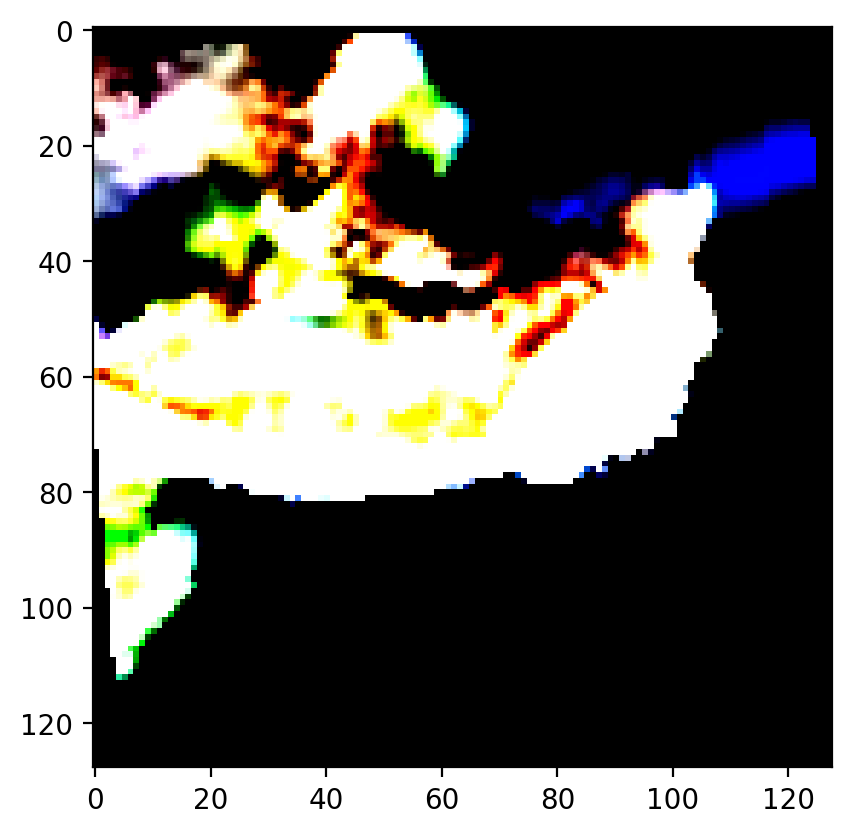

In [15]:
perm = torch.randperm(784)
random.seed(time.time())
train_df, test_df = train_test_split(df_cleaned, test_size=0.2, random_state=random.randint(0, 100))
#train_df, test_df = train_test_split(distr_color, test_size=0.2, random_state=random.randint(0, 100))
#train_df, val_df = train_test_split(train_df, test_size=0.1, random_state=random.randint(0, 100))
#test_df = drop_rows(test_df, image_names_to_drop)
print(len(train_df), len(test_df))
#print(len(train_df), len(val_df), len(test_df))

batch_size = 32
gecko_dataloader_train = Df_Loader(train_df, batch_size=batch_size, shuffle=True, transform=transform)
#gecko_dataloader_val = Df_Loader(val_df, batch_size=batch_size, shuffle=True)
gecko_dataloader_test = Df_Loader(test_df, batch_size=batch_size, shuffle=True, transform=transform)

image, _ = gecko_dataloader_test.dataset.__getitem__(0)
image = image.permute(1,2,0)
plt.imshow(image, cmap=plt.cm.binary)

### Model Definition

In [ ]:
class Gecko_Color_Alpha_Star_at67percent(nn.Module):
    def __init__(self, num_classes):
        super(Gecko_Color_Alpha, self).__init__()
        self.conv1 = nn.Conv2d(3, 128, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(128)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.elu1 = nn.ELU()
        #self.dropout1 = nn.Dropout(0.15)

        self.conv2 = nn.Conv2d(128, 192, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(192)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.elu2 = nn.ELU()
        #self.dropout2 = nn.Dropout(0.15)

        self.conv3 = nn.Conv2d(192, 384, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(384)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.elu3 = nn.ELU()
        self.dropout3 = nn.Dropout(0.15)

        self.conv4 = nn.Conv2d(384, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.pool4 = nn.MaxPool2d(2, 2)
        self.elu4 = nn.ELU()
        self.dropout4 = nn.Dropout(0.15)

        conv_size = im_size // 2 // 2 
        self.fc1 = nn.Linear(192 * conv_size * conv_size, 128)
        self.fc2 = nn.Linear(128, 192)
        self.dropout4 = nn.Dropout(0.15)
        self.fc3 = nn.Linear(192, 6)

    def forward(self, x):
        x = self.pool1(self.elu1(self.bn1(self.conv1(x))))
       # x = self.dropout1(x)

        x = self.pool2(self.elu2(self.bn2(self.conv2(x))))
        #x = self.dropout2(x)

        #x = self.pool3(self.elu3(self.bn3(self.conv3(x))))
        #x = self.dropout3(x)

        #x = self.pool4(self.elu4(self.bn4(self.conv4(x))))
        #x = self.dropout4(x)

        x = x.view(x.size(0), -1)
        x = nn.functional.relu(self.fc1(x)) # add batch norm here
        x = self.dropout4(x)
        x = nn.functional.softmax(self.fc2(x))
        return x

In [28]:
class Gecko_Color(nn.Module):
    def __init__(self, num_classes):
        super(Gecko_Color, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=5, padding=1)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        #self.pool2 = nn.pyramid_pool2d(2, 2)
        self.dropout1 = nn.Dropout(0.15)
        self.dropout2 = nn.Dropout(0.5)
        self.dropout3 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(64 * 15 * 15, 128)
        self.reg1 = nn.BatchNorm2d(32)
        self.fc2 = nn.Linear(128, 6)

    def forward(self, x):
        x = self.pool1(nn.functional.relu(self.conv1(x)))
        x = self.dropout1(x)
        x = self.pool1(nn.functional.relu(self.conv2(x)))
        x = self.dropout2(x)
        x = x.view(x.size(0), -1)
        x = nn.functional.relu(self.fc1(x))
        x = self.dropout3(x)
        x = nn.functional.softmax(self.fc2(x))
        return x
    
class Gecko_Color_Triple(nn.Module):
    def __init__(self, num_classes):
        super(Gecko_Color_Triple, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        #self.pool2 = nn.pyramid_pool2d(2, 2)
        self.dropout1 = nn.Dropout(0.15)
        self.dropout2 = nn.Dropout(0.5)
        self.dropout3 = nn.Dropout(0.5)
        self.dropout4 = nn.Dropout(0.4)
        conv_size = im_size // 2 // 2 // 2
        self.fc1 = nn.Linear(64 * conv_size * conv_size, 128)
        self.reg1 = nn.BatchNorm2d(32)
        self.fc2 = nn.Linear(128, 6)

    def forward(self, x):
        x = self.pool1(nn.functional.relu(self.conv1(x)))
        x = self.dropout1(x)
        #x = self.pool2(F.relu(self.conv2(x)))
        x = self.pool1(nn.functional.relu(self.conv2(x)))
        x = self.dropout2(x)
        x = self.pool1(nn.functional.relu(self.conv3(x)))
        x = self.dropout3(x)
        x = x.view(x.size(0), -1)
        x = nn.functional.relu(self.fc1(x))
        x = self.dropout4(x)
        x = nn.functional.softmax(self.fc2(x))
        return x

class Gecko_Color_New(nn.Module):
    def __init__(self, num_classes):
        super(Gecko_Color_New, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=4, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(64, 192, kernel_size=4, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(192, 384, kernel_size=4, padding=1)
        self.relu3 = nn.ReLU()

        self.conv4 = nn.Conv2d(384, 256, kernel_size=4, padding=1)
        self.relu4 = nn.ReLU()

        self.conv5 = nn.Conv2d(256, 256, kernel_size=4, padding=1)
        self.relu5 = nn.ReLU()
        self.pool5 = nn.MaxPool2d(2, 2)

        self.dropout1 = nn.Dropout(0.5)
        self.fc6 = nn.Linear(9216, 512)
        self.relu6 = nn.ReLU()

        self.dropout2 = nn.Dropout(0.5)
        self.fc7 = nn.Linear(512, 256)
        self.relu7  = nn.ReLU()
        self.fc8 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.relu3(self.conv3(x))
        x = self.relu4(self.conv4(x))
        x = self.pool5(self.relu5(self.conv5(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout1(x)
        x = self.relu6(self.fc6(x))
        x = self.dropout2(x)
        x = self.relu7(self.fc7(x))
        x = nn.functional.softmax(self.fc8(x))
    
class Gecko_Color_Simple(nn.Module):
    def __init__(self, num_classes):
        super(Gecko_Color_Simple, self).__init__()
        self.conv1 = nn.Conv2d(3, 128, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.pool2 = nn.AvgPool2d(2, 2)
        self.elu = nn.ELU()
        self.bn1 = nn.BatchNorm2d(64)
        self.bn2 = nn.BatchNorm2d(128)
        #self.pool2 = nn.pyramid_pool2d(2, 2)
        self.dropout1 = nn.Dropout(0.15)
        self.dropout2 = nn.Dropout(0.15)
        conv_size = im_size // 2 
        #self.fc1 = nn.Linear(123008, 128)
        self.fc1 = nn.Linear(128 * conv_size * conv_size, 128)
        self.reg1 = nn.BatchNorm2d(32)
        self.fc2 = nn.Linear(128, 6)

    def forward(self, x):
        #x = self.pool1(nn.functional.relu(self.conv1(x)))
        #x = self.pool1(nn.functional.relu(self.bn2(self.conv1(x))))
        x = self.pool1(self.elu(self.bn2(self.conv1(x))))
        #x = self.pool2(self.elu(self.bn1(self.conv1(x)))) # TRY THIS
        #x = self.pool2(nn.functional.relu(self.bn1(self.conv1(x)))) # TRY THIS
        x = self.dropout1(x)
        #x = self.pool2(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = nn.functional.relu(self.fc1(x))
        #x = nn.functional.relu(self.bn2(self.fc1(x)))
        x = self.dropout2(x) # Try lowering dropout rate
        x = nn.functional.softmax(self.fc2(x))
        return x
    
class ComplexModel(nn.Module):
    def __init__(self, num_classes):
        super(ComplexModel, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(256)
        self.conv4 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(512)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(512 * 8 * 8, 1024)
        self.bn5 = nn.BatchNorm1d(1024)
        self.fc2 = nn.Linear(1024, num_classes)

    def forward(self, x):
        x = self.pool(nn.functional.relu(self.bn1(self.conv1(x))))
        x = self.pool(nn.functional.relu(self.bn2(self.conv2(x))))
        x = self.pool(nn.functional.relu(self.bn3(self.conv3(x))))
        x = self.pool(nn.functional.relu(self.bn4(self.conv4(x))))
        x = x.view(x.size(0), -1)
        x = nn.functional.relu(self.bn5(self.fc1(x)))
        x = self.dropout2(x)
        x = self.fc2(x)
        return x

class Gecko_Color_Alpha(nn.Module):
    def __init__(self, num_classes):
        super(Gecko_Color_Alpha, self).__init__()
        self.conv1 = nn.Conv2d(3, 128, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(128)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.elu1 = nn.ELU()
        #self.dropout1 = nn.Dropout(0.15)

        self.conv2 = nn.Conv2d(128, 192, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(192)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.elu2 = nn.ELU()
        #self.dropout2 = nn.Dropout(0.15)

        self.conv3 = nn.Conv2d(192, 384, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(384)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.elu3 = nn.ELU()
        self.dropout3 = nn.Dropout(0.15)

        self.conv4 = nn.Conv2d(384, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.pool4 = nn.MaxPool2d(2, 2)
        self.elu4 = nn.ELU()
        self.dropout4 = nn.Dropout(0.15)

        conv_size = im_size // 2 // 2 // 2 // 2
        self.fc1 = nn.Linear(256 * conv_size * conv_size, 196)
        self.fc2 = nn.Linear(196, 128)
        self.dropout4 = nn.Dropout(0.15)
        self.fc3 = nn.Linear(128, 6)

    def forward(self, x):
        x = self.pool1(self.elu1(self.bn1(self.conv1(x))))
       # x = self.dropout1(x)

        x = self.pool2(self.elu2(self.bn2(self.conv2(x))))
        #x = self.dropout2(x)

        x = self.pool3(self.elu3(self.bn3(self.conv3(x))))
        #x = self.dropout3(x)

        x = self.pool4(self.elu4(self.bn4(self.conv4(x))))
        #x = self.dropout4(x)

        x = x.view(x.size(0), -1)
        x = nn.functional.relu(self.fc1(x)) # add batch norm here
        x = self.dropout4(x)
        x = nn.functional.relu(self.fc2(x))
        x = nn.functional.softmax(self.fc3(x))
        return x

### Custom Loss Functions

In [19]:
import torch
import torch.nn as nn

class PrecisionLoss(nn.Module):
    def __init__(self):
        super(PrecisionLoss, self).__init__()

    def forward(self, outputs, labels):
        # Apply sigmoid to get probabilities
        predicted = torch.sigmoid(outputs)
        predicted_labels = (predicted >= 0.5).float()

        # Calculate true positives and false positives
        true_positives = (predicted_labels * labels).sum().item()
        false_positives = (predicted_labels * (1 - labels)).sum().item()

        true_positives = (predicted_labels * labels).sum(dim=0)
        false_positives = (predicted_labels * (1 - labels)).sum(dim=0)

        # Calculate precision for each class
        precision = true_positives / (true_positives + false_positives + 1e-7)  # Add small value to avoid division by zero
            
        loss = 1 - precision.mean()

        return loss
    
class WeightedBCELoss(nn.Module):
    def __init__(self, pos_weight=1.0, neg_weight=1.0):
        super(WeightedBCELoss, self).__init__()
        self.pos_weight = pos_weight
        self.neg_weight = neg_weight

    def forward(self, outputs, labels):
        loss = -self.pos_weight * labels * torch.log(outputs) - self.neg_weight * (1 - labels) * torch.log(1 - outputs)
        return loss.mean()
    
    
class NEWLOSS(nn.Module):
    def __init__(self, pos_weight=1.0, neg_weight=1.0, acc_weight=1.0, prc_weight=1.0):
        super(NEWLOSS, self).__init__()
        self.pos_weight = pos_weight
        self.neg_weight = neg_weight
        self.acc_weight = acc_weight
        self.prc_weight = prc_weight

    def forward(self, outputs, labels):
        outputs = torch.sigmoid(outputs)
        preds = (outputs >= thresh_class).all(dim = 1).float().sum()
        acc = preds / labels.size(0)

        
        TPs = (preds * labels).sum()
        FPs = (preds * (1 - labels)).sum()
        #FNs = ((1 - preds) * labels).sum()
        prc = TPs / (TPs + FPs + 1e-7)


        loss = (-self.pos_weight * labels * torch.log(outputs) - self.neg_weight * (1 - labels) * torch.log(1 - outputs)) + self.acc_weight * (1 - acc) + self.prc_weight * ( 1 - prc)
        return loss.mean() 
    
class PrecisionWeightedBCELoss(nn.Module):
    def __init__(self, pos_weight=1.0, neg_weight=1.0, fdr_weight=1.0):
        super(PrecisionWeightedBCELoss, self).__init__()
        self.pos_weight = pos_weight
        self.neg_weight = neg_weight
        self.fdr_weight = fdr_weight

    def forward(self, outputs, labels):
        # Apply sigmoid to get probabilities
        outputs = torch.sigmoid(outputs)
        
        # Compute the weighted binary cross-entropy loss
        # - (y * log(p) + (1 - y) * log(1 - p))
        bce_loss = -(self.pos_weight * (labels * torch.log(outputs) + self.neg_weight * ((1 - labels)) * torch.log(1 - outputs)))
        #bce_loss = -self.pos_weight * labels * torch.log(outputs) - self.neg_weight * (1 - labels) * torch.log(1 - outputs)
        bce_loss = bce_loss.mean()
        
        # get precision metrics
        preds = (outputs >= thresh_class).float()
        TPs = (preds * labels).sum()
        FPs = (preds * (1 - labels)).sum()
        #TNs = ((1 - preds) * (1 - labels)).sum()
        #FNs = ((1 - preds) * labels).sum()

        fdr = FPs / (FPs + TPs + 1e-7)  # False discovery rate
        
        # Combine the BCE loss and the FDR penalty
        loss = bce_loss + self.fdr_weight * fdr
        
        return loss

### Training Function

In [506]:
num_classes = len(distr_color['Colors Raw'].iloc[0])
thresh_class = 0.6
learning_rate = 0.008 #0.008

#class_weights = torch.tensor([0.3, 0.3, 0.7, 0.7, 0.3, 0.3                                                                                                                                                   ]).to(device) 


#model = Gecko_Color(num_classes)
#model = Gecko_Color_Triple(num_classes)
#model = Gecko_Color_New(num_classes)
#model1 = Gecko_Color_Simple(num_classes)
model4 = Gecko_Color_Alpha(num_classes)
#criterion = nn.CrossEntropyLoss()
#criterion = NEWLOSS(acc_weight=2, prc_weight=0)
#criterion = nn.BCEWithLogitsLoss()
#criterion = nn.CrossEntropyLoss()

criterion = WeightedBCELoss(pos_weight=1.0, neg_weight=1.2)
#criterion = PrecisionWeightedBCELoss()
optimizer = torch.optim.SGD(model4.parameters(), lr=0.001, momentum=0.9)

#optimizer = torch.optim.SGD(model1.parameters(), lr=learning_rate)
#optimizer = optim.Adam(model.parameters(), lr=0.0001) 


##scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2, verbose=True)


def get_metrics(outputs, labels):
    correct = 0
    total = 0
    predicted = torch.sigmoid(outputs)
    predicted_labels = (predicted >= thresh_class).int()
    labels = labels.int()
    
    
    """correct = (predicted_labels == labels).sum().item() 
    if correct == 6:
        correct = 1
    total = labels.size(0)"""

    for preds, labs in zip(predicted_labels, labels):
        if torch.equal(preds, labs):
                correct += 1
        total += 1
    
    #correct = (predicted_labels == labels).sum().item()
    #total = labels.size(0) * len(base_color_labels)

    true_positives = (predicted_labels * labels).sum().item()
    false_positives = (predicted_labels * (1 - labels)).sum().item()
    false_negatives = ((1 - predicted_labels) * labels).sum().item()
    true_negatives = ((1 - predicted_labels) * (1 - labels)).sum().item()
    
    return correct, total, true_positives, false_positives, false_negatives, true_negatives

def train(model, train_loader, criterion, optimizer, num_epochs=5, clip_value=1.0):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.train()
    
    losses = []
    accuracies = []
    precisions = []
    recalls = [] 
    fprs = []
    fdrs = []

    
    for epoch in range(num_epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        TPs = 0
        FPs = 0
        FNs = 0
        TNs = 0

        for i, (images, labels) in enumerate(train_loader):
            images = images.to(device)
            labels = labels.to(device)


            """images = images.view(-1, im_size*im_size)
            images = images[:, perm]
            images = images.view(-1, 1, im_size, im_size)"""
        
            #forward pass
            optimizer.zero_grad()
            outputs = model(images)
            #l1_lambda = 0.001
            #l1_norm = sum(p.abs().sum() for p in model.parameters())
            loss = criterion(outputs, labels)# + l1_lambda * l1_norm

            #backward pass
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_value)
            optimizer.step()


            running_loss += loss.item()

            cort, tot, tp, fp, fn, tn = get_metrics(outputs, labels)
            correct += cort
            total += tot
            TPs += tp
            FPs += fp
            FNs += fn
            TNs += tn
            
            #if (i+1) % 100 == 0:
            #    print(f'Epoch [{epoch+1}], Step [{i+1}/{len(train_loader)}], Loss: {running_loss/len(train_loader)}')

        recall = TPs / (TPs + FNs + 1e-7)
        precision = TPs / (TPs + FPs + 1e-7)
        fpr =  FPs / (FPs + TNs  + 1e-7)
        fdr = FPs / (FPs + TPs + 1e-7)
        batch_accuracy = correct / total
        accuracies.append(batch_accuracy)
        precisions.append(precision)
        recalls.append(recall)
        fprs.append(fpr)
        fdrs.append(fdr)

        #scheduler.step(running_loss/len(train_loader))  # Update the learning rate based on the average loss


        print(f'End Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader)}, Precision: {precision}, Accuracy: {batch_accuracy}')
        losses.append(running_loss/len(train_loader))
    return losses, accuracies, precisions, recalls, fprs, fdrs

los, accs, precs, recs, fprs, fdrs= train(model4, gecko_dataloader_train, criterion, optimizer, num_epochs=50)

C:\Users\Ari Sinervo\AppData\Local\Temp\ipykernel_27620\3126571974.py:181: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  x = nn.functional.softmax(self.fc2(x))


End Epoch [1/50], Loss: 0.4645202811633315, Precision: 0.4776785712153221, Accuracy: 0.010428849902534114
End Epoch [2/50], Loss: 0.446184615572665, Precision: 0.49643705459252274, Accuracy: 0.06111111111111111
End Epoch [3/50], Loss: 0.4368537427666031, Precision: 0.5020181634459123, Accuracy: 0.09688109161793372
End Epoch [4/50], Loss: 0.4272335071430028, Precision: 0.5180302442606425, Accuracy: 0.12992202729044836
End Epoch [5/50], Loss: 0.420134944614963, Precision: 0.5196797865070154, Accuracy: 0.15077972709551657
End Epoch [6/50], Loss: 0.41291365788733103, Precision: 0.5520467836095893, Accuracy: 0.18304093567251462
End Epoch [7/50], Loss: 0.4073329542841867, Precision: 0.5549222797783699, Accuracy: 0.20760233918128654
End Epoch [8/50], Loss: 0.39953824348538836, Precision: 0.5693520571429084, Accuracy: 0.22387914230019493
End Epoch [9/50], Loss: 0.3952944214655974, Precision: 0.5792286245218581, Accuracy: 0.24064327485380116
End Epoch [10/50], Loss: 0.38930645074428427, Precisi

In [ ]:
import tqdm

def train_simple(model, data_loader, optimizer, criterion, num_epochs=50):
    optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.train()
    for epoch in tqdm.tqdm(range(num_epochs)):
        running_loss = 0.0
        for i, batch in enumerate(data_loader):
            images, labels = batch
            images = images.to(device)
            labels = labels.to(device)
        
            optimizer.zero_grad()
        
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            if i % 2000 == 1999:
                print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(data_loader)}], Loss: {running_loss/2000}')
                running_loss = 0.0
    return running_loss

num_classes = len(distr_color['Colors Raw'].iloc[0])
model = Gecko_Color_Alpha(num_classes)
criterion = nn.CrossEntropyLoss()
#criterion = WeightedBCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
train_simple(model, gecko_dataloader_train, optimizer, criterion)

  0%|          | 0/50 [00:00<?, ?it/s]C:\Users\Ari Sinervo\AppData\Local\Temp\ipykernel_17452\570839761.py:212: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  x = nn.functional.softmax(self.fc3(x))
 34%|███▍      | 17/50 [24:01<46:17, 84.17s/it] 

#### Train & Val

In [18]:
num_classes = len(distr_color['Colors Raw'].iloc[0])
thresh_class = 0.6
learning_rate = 0.01

#model = Gecko_Color(num_classes)
#model = Gecko_Color_Triple(num_classes)
model1 = Gecko_Color_Simple(num_classes)
#criterion = nn.CrossEntropyLoss()
#criterion = NEWLOSS(acc_weight=2, prc_weight=0)
#criterion = nn.BCEWithLogitsLoss()
criterion = WeightedBCELoss(pos_weight=1.0, neg_weight=1.2)
#criterion = PrecisionWeightedBCELoss()
optimizer = torch.optim.SGD(model1.parameters(), lr=learning_rate)
#optimizer = optim.Adam(model.parameters(), lr=0.0001)

def get_metrics(outputs, labels):
    correct = 0
    total = 0
    predicted = torch.sigmoid(outputs)
    predicted_labels = (predicted >= thresh_class).int()
    labels = labels.int()
    
    
    """correct = (predicted_labels == labels).sum().item() 
    if correct == 6:
        correct = 1
    total = labels.size(0)"""

    for preds, labs in zip(predicted_labels, labels):
        if torch.equal(preds, labs):
                correct += 1
        total += 1
    
    #correct = (predicted_labels == labels).sum().item()
    #total = labels.size(0) * len(base_color_labels)

    true_positives = (predicted_labels * labels).sum().item()
    false_positives = (predicted_labels * (1 - labels)).sum().item()
    false_negatives = ((1 - predicted_labels) * labels).sum().item()
    true_negatives = ((1 - predicted_labels) * (1 - labels)).sum().item()
    
    return correct, total, true_positives, false_positives, false_negatives, true_negatives


def train_and_validate(model, train_loader, val_loader, criterion, optimizer, num_epochs=5, clip_value=1.0):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.train()
    
    losses = []
    losses_val = []

    accuracies = []
    accuracies_val = []

    precisions = []
    precisions_val = []

    recalls = [] 
    recalls_val = []

    fprs = []
    fprs_val = []   

    fdrs = []
    fdrs_val = []

    
    for epoch in range(num_epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        TPs = 0
        FPs = 0
        FNs = 0
        TNs = 0

        running_loss_val = 0.0
        correct_val = 0
        total_val = 0
        TPs_val = 0
        FPs_val = 0
        FNs_val = 0
        TNs_val = 0

        for i, (images, labels) in enumerate(train_loader):
            images = images.to(device)
            labels = labels.to(device)


            """images = images.view(-1, im_size*im_size)
            images = images[:, perm]
            images = images.view(-1, 1, im_size, im_size)"""
        
            #forward pass
            optimizer.zero_grad()
            outputs = model(images)
            #l1_lambda = 0.001
            #l1_norm = sum(p.abs().sum() for p in model.parameters())
            loss = criterion(outputs, labels)# + l1_lambda * l1_norm

            #backward pass
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_value)
            optimizer.step()


            running_loss += loss.item()

            cort, tot, tp, fp, fn, tn = get_metrics(outputs, labels)
            correct += cort
            total += tot
            TPs += tp
            FPs += fp
            FNs += fn
            TNs += tn
            
            if (i+1) % 100 == 0:
                print(f'Epoch [{epoch+1}], Step [{i+1}/{len(train_loader)}], Loss: {running_loss/len(train_loader)}')
        
        model.eval()
        for i, (images, labels) in enumerate(val_loader):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            #print(outputs)
            loss += torch.sum(criterion(outputs, labels)).item()

            cort, tot, tp, fp, fn, tn = get_metrics(outputs, labels)
            correct_val += cort
            total_val += tot
            TPs_val += tp
            FPs_val += fp
            FNs_val += fn
            TNs_val += tn
        model.train()

        recall = TPs / (TPs + FNs + 1e-7)
        recall_val = TPs_val / (TPs_val + FNs_val + 1e-7)
        precision = TPs / (TPs + FPs + 1e-7)
        precision_val = TPs_val / (TPs_val + FPs_val + 1e-7)
        fpr =  FPs / (FPs + TNs  + 1e-7)
        fpr_val =  FPs_val / (FPs_val + TNs_val  + 1e-7)
        fdr = FPs / (FPs + TPs + 1e-7)
        fdr_val = FPs_val / (FPs_val + TPs_val + 1e-7)
        batch_accuracy = correct / total
        batch_accuracy_val = correct_val / total_val
        accuracies.append(batch_accuracy)
        accuracies_val.append(batch_accuracy_val)

        precisions.append(precision)
        precisions_val.append(precision_val)

        recalls.append(recall)
        recalls_val.append(recall_val)

        fprs.append(fpr)
        fprs_val.append(fpr_val)

        fdrs.append(fdr)
        fdrs_val.append(fdr_val)

        #scheduler.step(running_loss/len(train_loader))  # Update the learning rate based on the average loss


        print(f'End Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader)}, Precision: {precision}, Accuracy: {batch_accuracy}')
        losses.append(running_loss/len(train_loader))
        losses_val.append(loss/len(val_loader))
    return losses, losses_val, accuracies, accuracies_val, precisions, precision_val, recalls, recall_val, fprs, fpr_val, fdrs, fdr_val

los, los_val, accs, accs_val, precs, precs_val, recs, recs_val, fprs, fprs_val, fdrs, fdrs_val = train_and_validate(model1, gecko_dataloader_train, gecko_dataloader_val, criterion, optimizer, num_epochs=100)

C:\Users\Ari Sinervo\AppData\Local\Temp\ipykernel_14196\3435662155.py:83: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  x = nn.functional.softmax(self.fc2(x))


Epoch [1], Step [100/287], Loss: 0.16627268934499095
Epoch [1], Step [200/287], Loss: 0.3308991831354148
End Epoch [1/100], Loss: 0.4730206260697767, Precision: 0.3965201464838351, Accuracy: 0.03847411444141689
Epoch [2], Step [100/287], Loss: 0.16308924441553574
Epoch [2], Step [200/287], Loss: 0.3241850907171229
End Epoch [2/100], Loss: 0.4651327411472174, Precision: 0.4482501861170327, Accuracy: 0.0529700272479564
Epoch [3], Step [100/287], Loss: 0.16178241797855922
Epoch [3], Step [200/287], Loss: 0.3239178687645583
End Epoch [3/100], Loss: 0.46264763088176475, Precision: 0.4533437013644367, Accuracy: 0.05133514986376022
Epoch [4], Step [100/287], Loss: 0.15997340724858672
Epoch [4], Step [200/287], Loss: 0.3205484046960957
End Epoch [4/100], Loss: 0.4591818802863463, Precision: 0.4626959247358811, Accuracy: 0.06626702997275204
Epoch [5], Step [100/287], Loss: 0.15899260554994857
Epoch [5], Step [200/287], Loss: 0.31817799983124284
End Epoch [5/100], Loss: 0.4571118325721927, Preci

In [25]:
print(precs_val)

0.6446700506523402


TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

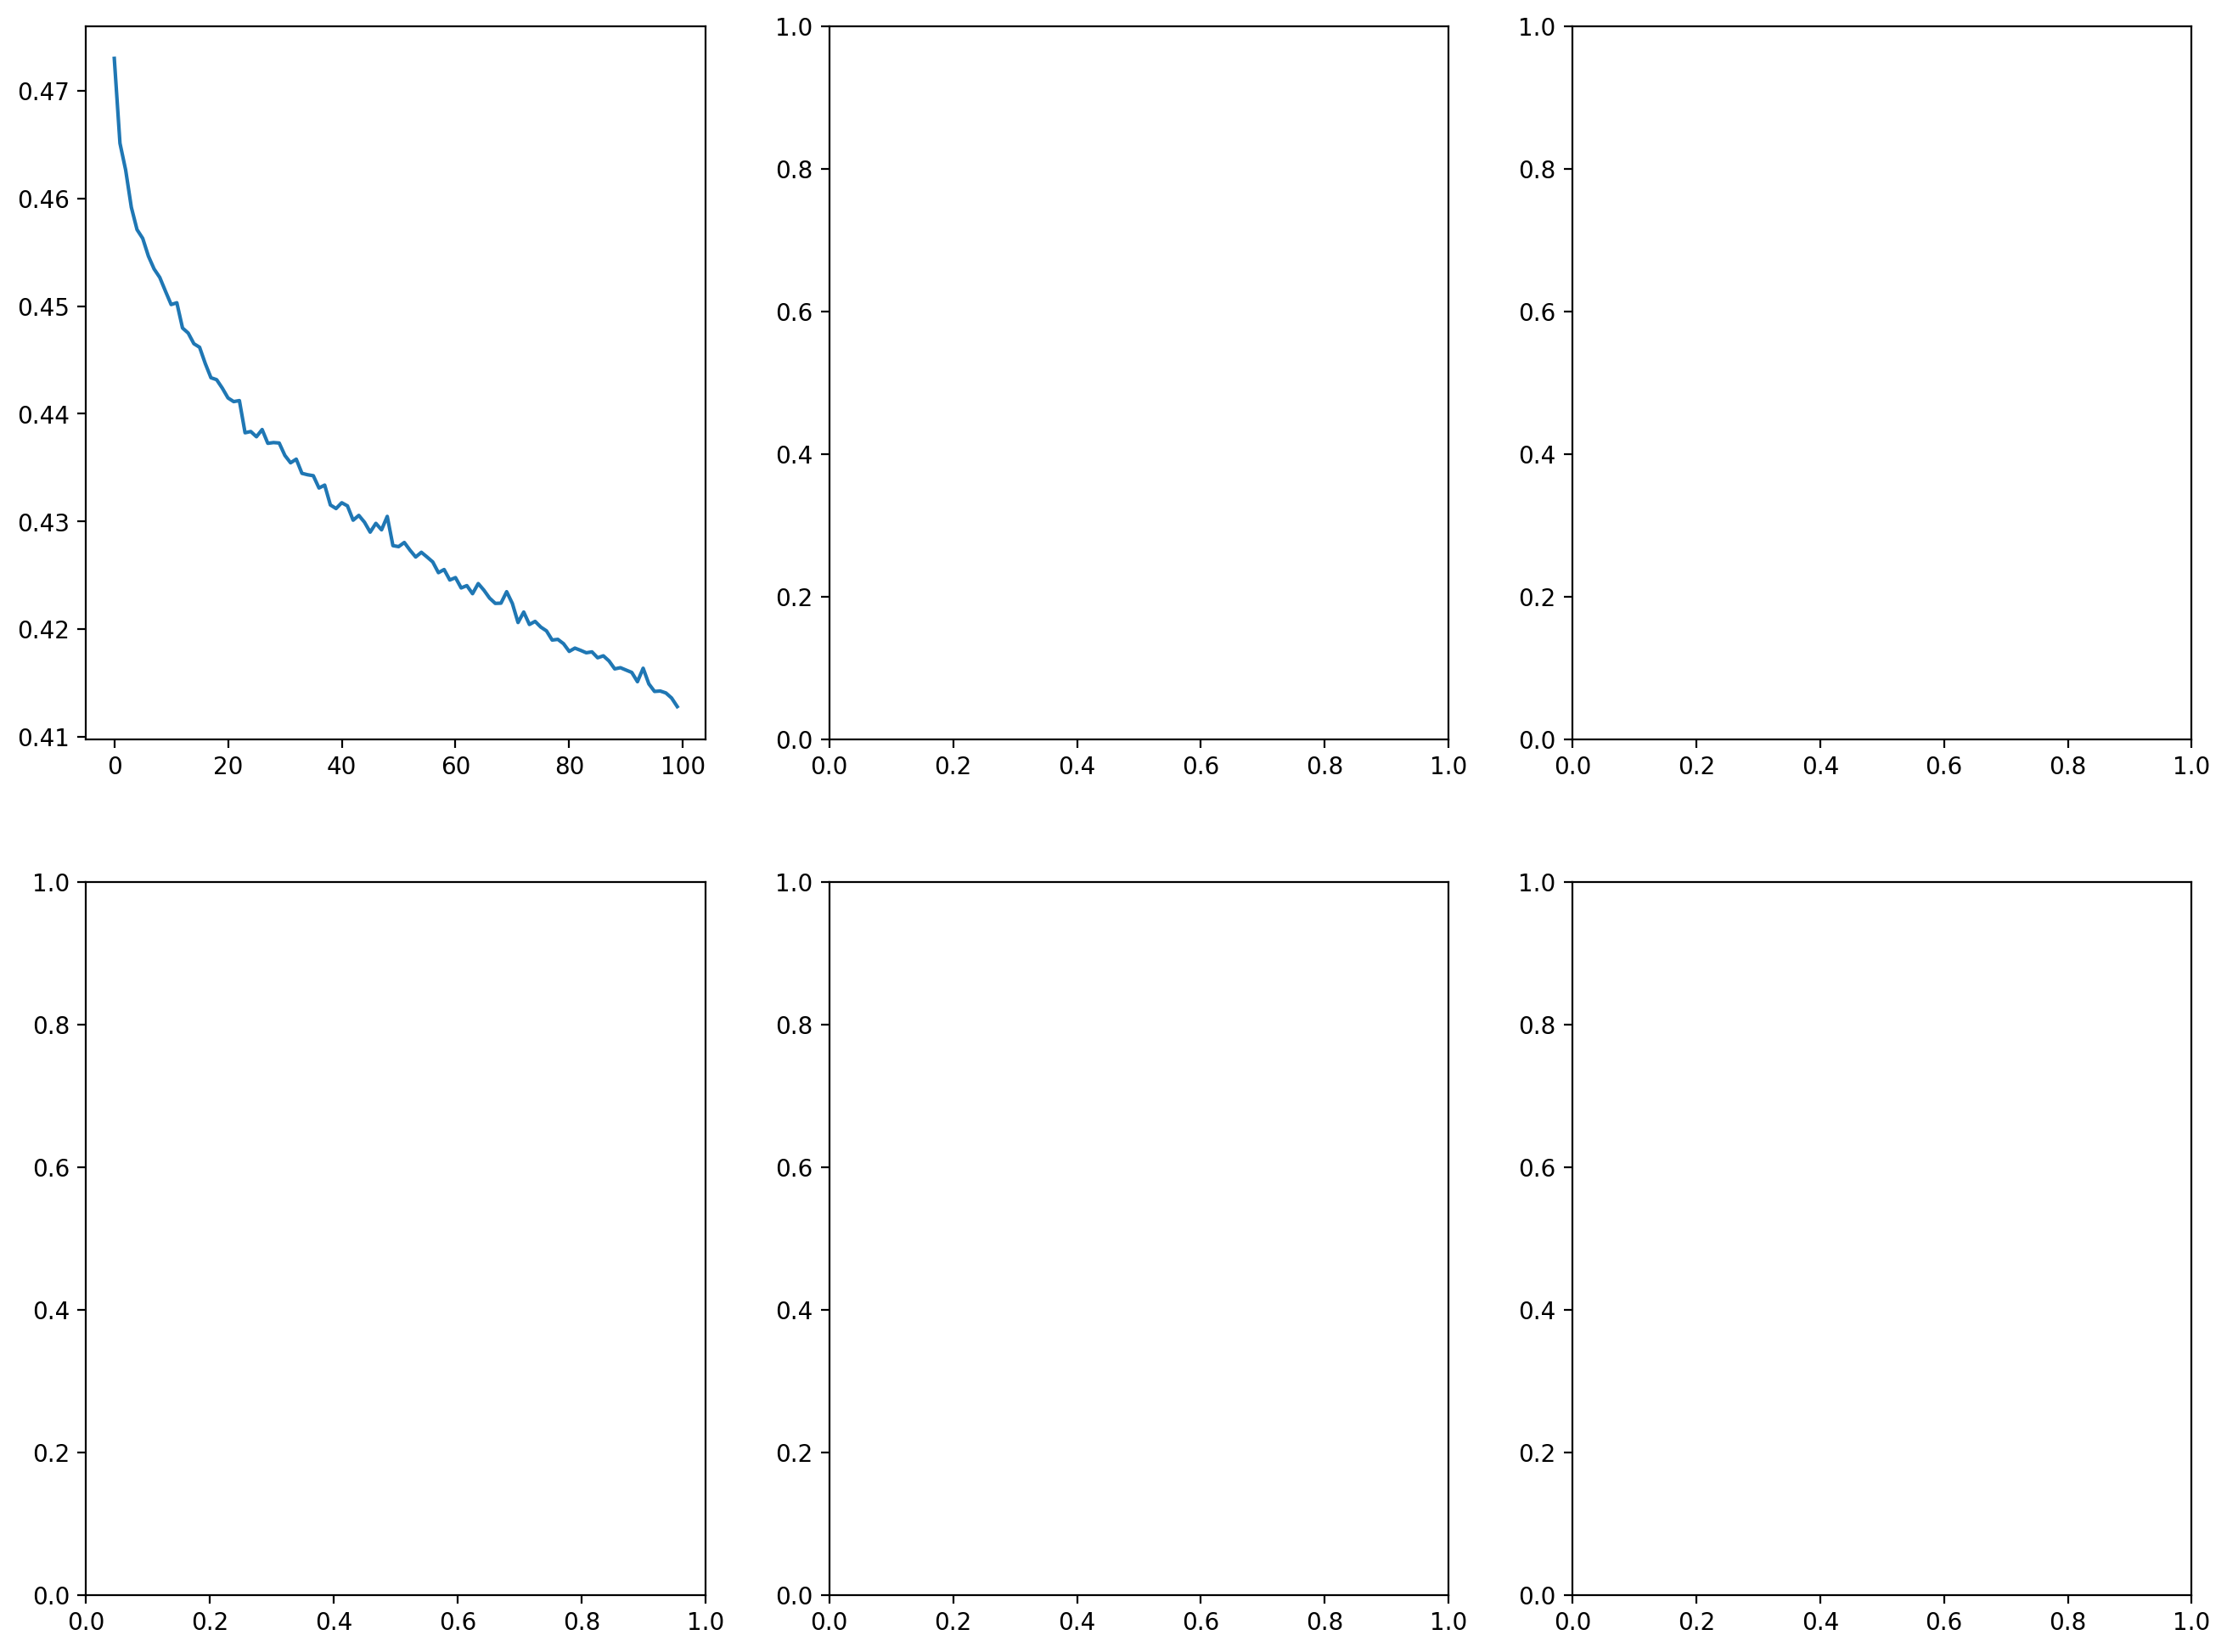

In [19]:

X=  """
    ABC
    DEF
    """
fig, plot = plt.subplot_mosaic(X, figsize=(16, 12))
plot["A"].plot(range(len(los)), los)
plot["A"].plot(range(len(los_val)), los_val)
plot["A"].set_title("Loss")
plot["A"].set_xlabel("Epoch")
plot["A"].set_ylabel("Loss")

plot["B"].plot(accs)
plot["B"].plot(accs_val)
plot["B"].set_title("Accuracy")
plot["B"].set_xlabel("Epoch")
plot["B"].set_ylabel("Accuracy")

plot["C"].plot(precs)
plot["C"].plot(precs_val)
plot["C"].set_title("Precision")
plot["C"].set_xlabel("Epoch")
plot["C"].set_ylabel("Precision")

plot["D"].plot(recs)
plot["D"].plot(recs_val)
plot["D"].set_title("Recall")
plot["D"].set_xlabel("Epoch")
plot["D"].set_ylabel("Recall")

plot["E"].plot(fprs)
plot["E"].plot(fprs_val)
plot["E"].set_title("False Positivity rate")
plot["E"].set_xlabel("Epoch")
plot["E"].set_ylabel("False Positivity rate")

plot["F"].plot(fprs)
plot["F"].plot(fprs_val)
plot["F"].set_title("False Discovery Rate")
plot["F"].set_xlabel("Epoch")
plot["F"].set_ylabel("False Discovery Rate")


plt.show()

# Model Evaluation

NameError: name 'los' is not defined

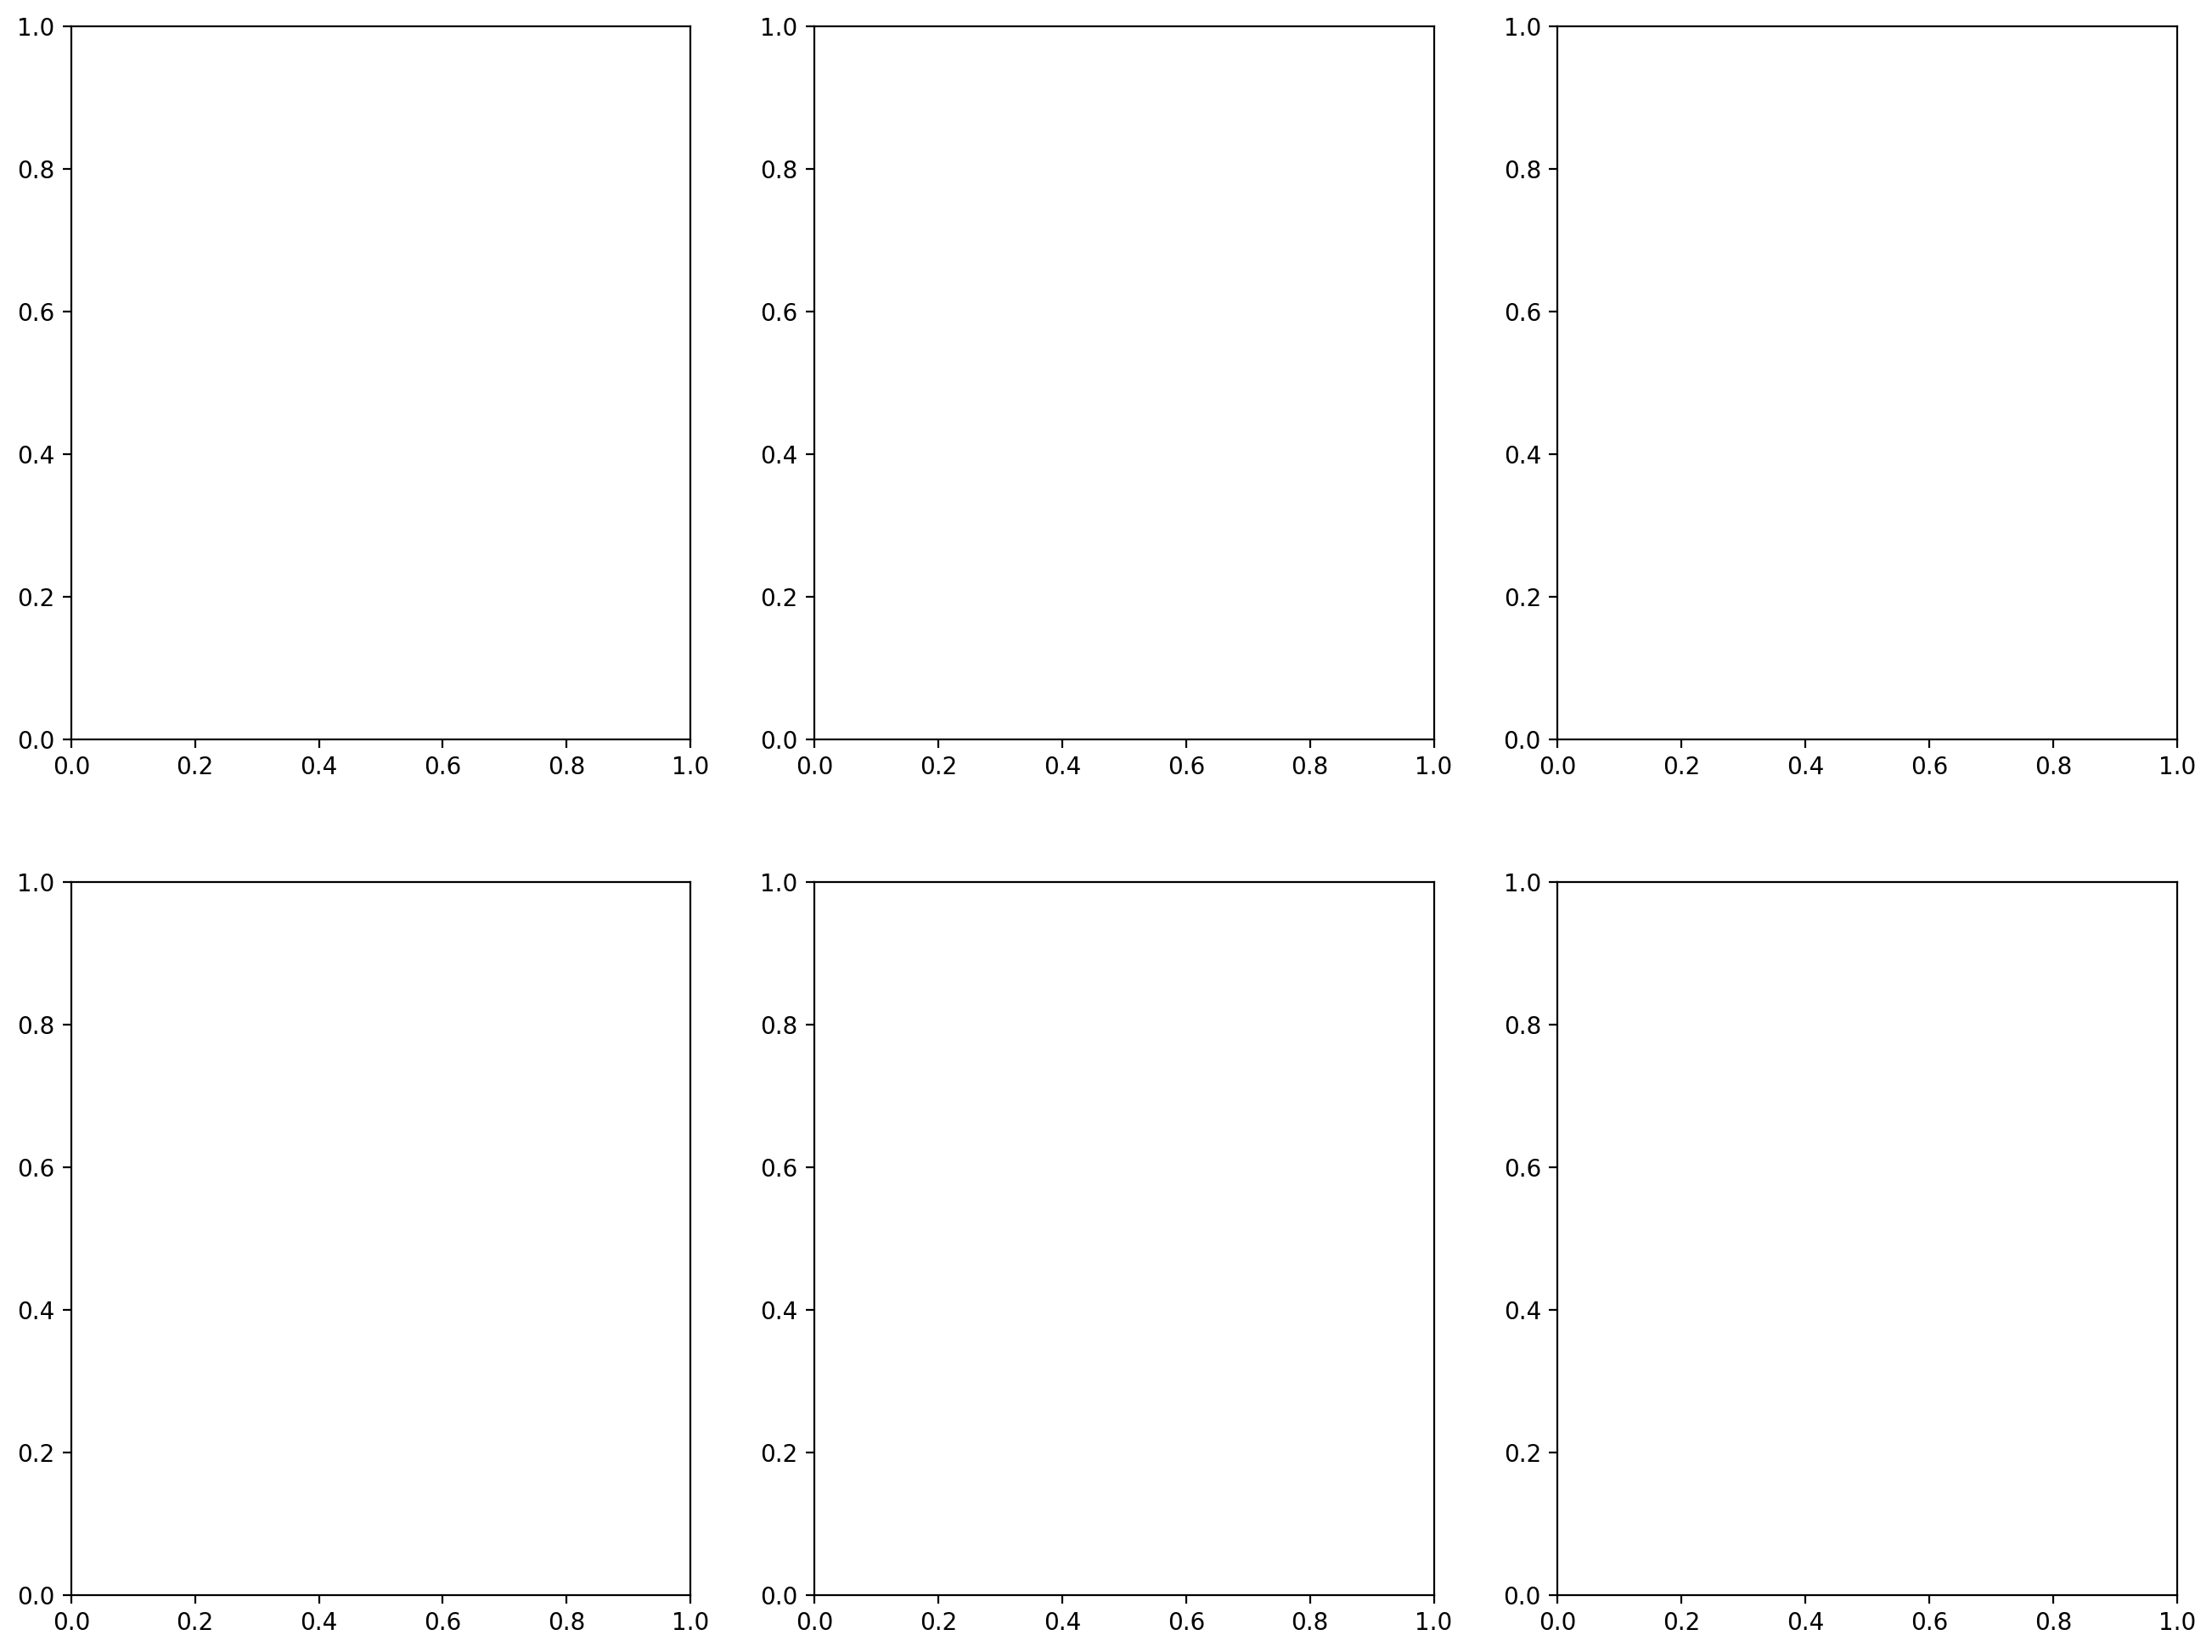

In [23]:

X=  """
    ABC
    DEF
    """
fig, plot = plt.subplot_mosaic(X, figsize=(16, 12))
plot["A"].plot(range(len(los)), los)
plot["A"].set_title("Loss")
plot["A"].set_xlabel("Epoch")
plot["A"].set_ylabel("Loss")

plot["B"].plot(accs)
plot["B"].set_title("Accuracy")
plot["B"].set_xlabel("Epoch")
plot["B"].set_ylabel("Accuracy")

plot["C"].plot(precs)
plot["C"].set_title("Precision")
plot["C"].set_xlabel("Epoch")
plot["C"].set_ylabel("Precision")

plot["D"].plot(recs)
plot["D"].set_title("Recall")
plot["D"].set_xlabel("Epoch")
plot["D"].set_ylabel("Recall")

plot["E"].plot(fprs)
plot["E"].set_title("False Positivity rate")
plot["E"].set_xlabel("Epoch")
plot["E"].set_ylabel("False Positivity rate")

plot["F"].plot(fprs)
plot["F"].set_title("False Discovery Rate")
plot["F"].set_xlabel("Epoch")
plot["F"].set_ylabel("False Discovery Rate")


plt.show()

2 epochs at 396x396 takes 11 minutes

In [25]:
thresh_class = 0.6
def evaluate_accuracy(model, dataloader, device):
    model.eval()  # Set the model to evaluation mode
    
    with torch.no_grad():  # Disable gradient calculation
        correct = 0
        correct_multi = 0
        total = 0
        total_multi = 0
        loss = 0
        TPs = 0
        FPs = 0
        FNs = 0
        TNs = 0
        full_negatives = 0
        miss_negatives = 0
        lookout_negatives = []

        criterion = criterion = WeightedBCELoss(pos_weight=1.0, neg_weight=1.2)

        for images, labels in dataloader: # loop through batches
            images, labels = images.to(device), labels.to(device)
            #print(len(labels))
            #print(len(images))
            outputs = model(images)
            #print(outputs)
            loss += torch.sum(criterion(outputs, labels)).item()

            predicted = torch.sigmoid(outputs)
            predicted_labels = (predicted > thresh_class).int()
            #print(predicted)#, predicted, outputs) 
            #print(len(predicted_labels))
            labels = labels.int()
            total += labels.size(0) * len(base_color_labels)

            for items, prediction in zip(labels, predicted_labels): # loop through individual labels in batch
                if torch.equal(items, prediction): # increment correct if all labels are correct
                    correct += 1
                if items.sum().item() > 1: # increment mutli-label correct
                    if torch.equal(items, prediction):
                        correct_multi += 1
                    total_multi += 1
                    """correct_multi += (prediction == items).sum().item()
                    total_multi += 6"""
                negatives_inLoop_check = abs(((prediction - 1) * items).sum().item())
                #print(f"negatives_inLoop_check: {negatives_inLoop_check}")
                if negatives_inLoop_check != 0:
                    if(items.sum().item() == 0):
                        full_negatives += 1
                    else: 
                        lookout_negatives.append(negatives_inLoop_check)
                        miss_negatives += 1
                    

                    #print(f"items: {items}, prediction: {prediction}")
                    #print(f"prediction: {items * (prediction - 1)}")
                    pass



            # Get number of correctly predicted labels
            #correct += (predicted_labels == labels).sum().item()

            
            """if (predicted_labels == labels).sum().item() == 6:
                correct += 1"""
            """if ((1 - predicted_labels) * labels).sum().item() != 0:
                if ((1 - predicted_labels) * labels).sum().item() == 6:
                    full_negatives += 1
                else:
                    lookout_negatives.append(((1 - predicted_labels) * labels).sum().item())
                    miss_negatives += 1
"""
            
            # Get discovery metrics
            TPs += (predicted_labels * labels).sum().item()
            FPs += abs((predicted_labels * (1 - labels)).sum().item())
            FNs += abs(((1 - predicted_labels) * labels).sum().item())
            TNs += ((1 - predicted_labels) * (1 - labels)).sum().item()
    


    precision = TPs / (TPs + FPs + 1e-7)
    recall = TPs / (TPs + FNs + 1e-7)
    false_positive_rate = FPs / (FPs + TNs  + 1e-7)
    false_discovery_rate = FPs / (FPs + TPs + 1e-7)
    false_negative_rate = FNs / (FNs + TPs + 1e-7)
        
    accuracy = 100 * correct / ( total / 6)
    if total_multi:
        accuracy_multi = 100 * correct_multi / total_multi
    else: 
        accuracy_multi = "N/A"
    loss /= len(dataloader.dataset)
    print(f'''
    __________________________________________________________________________
    ____________________________ MODEL EVALUATION ____________________________\n
    ---[]---  Accuracy: {accuracy:.2f}%, {accuracy_multi}% (multiclasses)
    ---[]---  Loss: {loss}
    ---[]---  ---------------------------------------------------------------
    ---[]---  |\tTrue Positives: {TPs}\t|\tFalse Positives: {FPs}\t|
    ---[]---  |\tFalse Negatives: {FNs}\t|\tTrue Negatives : {TNs}\t|
    ---[]---  ---------------------------------------------------------------
    ---[]---  Total Labels: {int(total / 6)}
    ---[]---  Precision: {(precision * 100):.2f}%
    ---[]---  Recall: {(recall * 100):.2f}%
    ---[]---  False Positive Rate: {(false_positive_rate * 100):.2f}%
    ---[]---  False Discovery Rate: {(false_discovery_rate * 100):.2f}%
    ---[]---  False negative Rate: {(false_negative_rate * 100):.2f}%
    ---[]---  Correct: {correct}
    ---[]---  Number of Full Negatives : {full_negatives}
    ---[]---  Number of misclassified negatives : {miss_negatives}\n''') #figure out what exactly is causing false negatives, is it zeors everywhere or a misclassification 


    model.train()  # Set the model back to training mode
    return accuracy, lookout_negatives

color_accuracy, lookout = evaluate_accuracy(model, gecko_dataloader_test, device)

print(lookout)

C:\Users\Ari Sinervo\AppData\Local\Temp\ipykernel_17452\1471418749.py:212: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  x = nn.functional.softmax(self.fc3(x))



    __________________________________________________________________________
    ____________________________ MODEL EVALUATION ____________________________

    ---[]---  Accuracy: 70.86%, N/A% (multiclasses)
    ---[]---  Loss: nan
    ---[]---  ---------------------------------------------------------------
    ---[]---  |	True Positives: 2472	|	False Positives: 1019	|
    ---[]---  |	False Negatives: 956	|	True Negatives : 16121	|
    ---[]---  ---------------------------------------------------------------
    ---[]---  Total Labels: 3428
    ---[]---  Precision: 70.81%
    ---[]---  Recall: 72.11%
    ---[]---  False Positive Rate: 5.95%
    ---[]---  False Discovery Rate: 29.19%
    ---[]---  False negative Rate: 27.89%
    ---[]---  Correct: 2429
    ---[]---  Number of Full Negatives : 0
    ---[]---  Number of misclassified negatives : 956

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [494]:
evaluate_accuracy(model, gecko_dataloader_test, device)

C:\Users\Ari Sinervo\AppData\Local\Temp\ipykernel_27620\3126571974.py:130: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  x = nn.functional.softmax(self.fc2(x))



    __________________________________________________________________________
    ____________________________ MODEL EVALUATION ____________________________

    ---[]---  Accuracy: 60.33%, N/A% (multiclasses)
    ---[]---  Loss: nan
    ---[]---  ---------------------------------------------------------------
    ---[]---  |	True Positives: 1591	|	False Positives: 1044	|
    ---[]---  |	False Negatives: 975	|	True Negatives : 11786	|
    ---[]---  ---------------------------------------------------------------
    ---[]---  Total Labels: 2566
    ---[]---  Precision: 60.38%
    ---[]---  Recall: 62.00%
    ---[]---  False Positive Rate: 8.14%
    ---[]---  False Discovery Rate: 39.62%
    ---[]---  False negative Rate: 38.00%
    ---[]---  Correct: 1548
    ---[]---  Number of Full Negatives : 0
    ---[]---  Number of misclassified negatives : 975



(60.327357755261104,
 [1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,

In [526]:
evaluate_accuracy(model3, gecko_dataloader_test, device)

C:\Users\Ari Sinervo\AppData\Local\Temp\ipykernel_27620\3126571974.py:130: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  x = nn.functional.softmax(self.fc2(x))



    __________________________________________________________________________
    ____________________________ MODEL EVALUATION ____________________________

    ---[]---  Accuracy: 72.17%, N/A% (multiclasses)
    ---[]---  Loss: nan
    ---[]---  ---------------------------------------------------------------
    ---[]---  |	True Positives: 1256	|	False Positives: 483	|
    ---[]---  |	False Negatives: 458	|	True Negatives : 8087	|
    ---[]---  ---------------------------------------------------------------
    ---[]---  Total Labels: 1714
    ---[]---  Precision: 72.23%
    ---[]---  Recall: 73.28%
    ---[]---  False Positive Rate: 5.64%
    ---[]---  False Discovery Rate: 27.77%
    ---[]---  False negative Rate: 26.72%
    ---[]---  Correct: 1237
    ---[]---  Number of Full Negatives : 0
    ---[]---  Number of misclassified negatives : 458



(72.1703617269545,
 [1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
 

In [543]:
evaluate_accuracy(model5, gecko_dataloader_test, device)

C:\Users\Ari Sinervo\AppData\Local\Temp\ipykernel_27620\3126571974.py:130: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  x = nn.functional.softmax(self.fc2(x))



    __________________________________________________________________________
    ____________________________ MODEL EVALUATION ____________________________

    ---[]---  Accuracy: 63.48%, N/A% (multiclasses)
    ---[]---  Loss: nan
    ---[]---  ---------------------------------------------------------------
    ---[]---  |	True Positives: 2236	|	False Positives: 1272	|
    ---[]---  |	False Negatives: 1192	|	True Negatives : 15868	|
    ---[]---  ---------------------------------------------------------------
    ---[]---  Total Labels: 3428
    ---[]---  Precision: 63.74%
    ---[]---  Recall: 65.23%
    ---[]---  False Positive Rate: 7.42%
    ---[]---  False Discovery Rate: 36.26%
    ---[]---  False negative Rate: 34.77%
    ---[]---  Correct: 2176
    ---[]---  Number of Full Negatives : 0
    ---[]---  Number of misclassified negatives : 1192



(63.477246207701285,
 [1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,

In [554]:
evaluate_accuracy(model6, gecko_dataloader_test, device)

C:\Users\Ari Sinervo\AppData\Local\Temp\ipykernel_27620\696535408.py:210: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  x = nn.functional.softmax(self.fc2(x))



    __________________________________________________________________________
    ____________________________ MODEL EVALUATION ____________________________

    ---[]---  Accuracy: 67.04%, N/A% (multiclasses)
    ---[]---  Loss: nan
    ---[]---  ---------------------------------------------------------------
    ---[]---  |	True Positives: 2353	|	False Positives: 1127	|
    ---[]---  |	False Negatives: 1075	|	True Negatives : 16013	|
    ---[]---  ---------------------------------------------------------------
    ---[]---  Total Labels: 3428
    ---[]---  Precision: 67.61%
    ---[]---  Recall: 68.64%
    ---[]---  False Positive Rate: 6.58%
    ---[]---  False Discovery Rate: 32.39%
    ---[]---  False negative Rate: 31.36%
    ---[]---  Correct: 2298
    ---[]---  Number of Full Negatives : 0
    ---[]---  Number of misclassified negatives : 1075



(67.03617269544924,
 [1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,


In [69]:
Base = torch.tensor([0, 0, 0, 1, 1, 1])

Test1 = torch.tensor([0, 0, 1, 1, 0, 0])
Test2 = torch.tensor([0, 1, 0, 1, 0, 0])
Test3 = torch.tensor([0, 0, 1, 0, 0, 1])

#(1 - predicted_labels) * labels).sum().item()

print(f"test one : {abs(((Test1) == (Base)).sum().item())}")
print(f"test one : {((Test2) * (Base - 1)).sum().item()}")
print(f"test one : {((Test3 - 1) * (Base - 1)).sum().item()}")
# only count positively if all the labels

# if one is off it's a total missmatch
4 

test one : 3
test one : -1
test one : 2


4

In [328]:
for images, labels in gecko_dataloader_test:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    predicted = torch.sigmoid(outputs)
    label = labels.int()
    print(outputs)
    break

C:\Users\Ari Sinervo\AppData\Local\Temp\ipykernel_27620\3126571974.py:130: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  x = nn.functional.softmax(self.fc2(x))


tensor([[4.6266e-04, 1.3517e-02, 9.6085e-03, 4.3273e-04, 9.4252e-01, 3.3456e-02],
        [1.4120e-08, 5.1524e-08, 6.0216e-08, 1.9647e-09, 9.9983e-01, 1.6578e-04],
        [7.7929e-09, 2.0873e-06, 6.7266e-08, 3.0853e-08, 8.1626e-05, 9.9992e-01],
        [2.3163e-03, 3.7692e-03, 1.2537e-03, 1.3341e-03, 3.3828e-01, 6.5305e-01],
        [9.8380e-08, 2.3460e-01, 3.6677e-06, 1.3716e-05, 7.6538e-01, 1.0055e-06],
        [2.0598e-05, 5.4966e-01, 1.6491e-05, 1.3815e-04, 4.4985e-01, 3.1530e-04],
        [1.1002e-06, 8.5881e-07, 3.8813e-07, 1.8851e-07, 9.2039e-04, 9.9908e-01],
        [1.0020e-08, 4.3187e-06, 2.5785e-08, 1.9600e-09, 1.0000e+00, 3.6336e-08],
        [6.8914e-08, 9.9763e-01, 1.4344e-05, 2.2809e-06, 2.3462e-03, 3.4969e-06],
        [2.9448e-10, 6.9893e-04, 8.3931e-09, 4.9575e-10, 9.9930e-01, 5.1266e-08],
        [3.9772e-11, 9.9013e-01, 8.7946e-09, 5.4520e-09, 9.8674e-03, 7.0278e-08],
        [7.9018e-07, 1.3621e-05, 5.5833e-08, 9.0859e-09, 9.9998e-01, 1.1496e-06],
        [2.6021e

In [313]:
print(predicted)

tensor([[0.5000, 0.5000, 0.5000, 0.5000, 0.7309, 0.5002],
        [0.5000, 0.5605, 0.5000, 0.5000, 0.6788, 0.5021],
        [0.5000, 0.7311, 0.5000, 0.5000, 0.5000, 0.5000],
        [0.5000, 0.7205, 0.5000, 0.5000, 0.5133, 0.5000],
        [0.5000, 0.5000, 0.5000, 0.5000, 0.5251, 0.7108],
        [0.5000, 0.7296, 0.5000, 0.5000, 0.5018, 0.5000],
        [0.5000, 0.5000, 0.5000, 0.5000, 0.7311, 0.5000],
        [0.5000, 0.7309, 0.5000, 0.5000, 0.5002, 0.5000],
        [0.5000, 0.6910, 0.5000, 0.5000, 0.5482, 0.5003],
        [0.5000, 0.5000, 0.5000, 0.5000, 0.7311, 0.5000],
        [0.5000, 0.5000, 0.5000, 0.5000, 0.7311, 0.5000],
        [0.5000, 0.5001, 0.5000, 0.5000, 0.7280, 0.5038],
        [0.5000, 0.5213, 0.5000, 0.5000, 0.7139, 0.5001],
        [0.5000, 0.5000, 0.5000, 0.5000, 0.7311, 0.5000],
        [0.5000, 0.5020, 0.5000, 0.5000, 0.7295, 0.5000],
        [0.5000, 0.5219, 0.5000, 0.5000, 0.7134, 0.5000],
        [0.5000, 0.5004, 0.5000, 0.5000, 0.7308, 0.5000],
        [0.500

In [329]:
print(label)

tensor([[0, 0, 1, 0, 0, 0],
        [0, 0, 0, 0, 1, 0],
        [0, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1],
        [0, 1, 0, 0, 0, 0],
        [1, 0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 1, 0],
        [1, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 0],
        [0, 0, 0, 0, 1, 0],
        [0, 0, 0, 0, 1, 0],
        [0, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 1, 0],
        [1, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1],
        [0, 1, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0],
        [0, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 0],
        [0, 1, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0],
        [0, 0, 0, 0, 1, 0],
        [1, 0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0, 0],
        [0, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 1, 0, 0, 0],
        [1, 1, 0, 0, 0, 0],
        [0, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 0]], device='cuda:0', dtype=torch.int32)


Improving the precision of your model involves several strategies, including tuning hyperparameters, improving data quality, and adjusting the model architecture. Precision is the ratio of true positives to the sum of true positives and false positives, and it measures the accuracy of the positive predictions.

Strategies to Increase Precision
Data Quality and Preprocessing:

Clean the Data: Ensure that the data is clean and free of noise.
Feature Engineering: Create new features that might help the model make better predictions.
Balanced Dataset: Ensure that the dataset is balanced or use techniques like oversampling/undersampling to handle class imbalance.
Model Architecture:

Complexity: Increase the complexity of the model by adding more layers or units, but be cautious of overfitting.
Regularization: Use techniques like dropout, L2 regularization, or batch normalization to prevent overfitting.
Hyperparameter Tuning:

Learning Rate: Adjust the learning rate to find the optimal value.
Batch Size: Experiment with different batch sizes.
Number of Epochs: Train the model for more epochs, but monitor for overfitting.
Threshold Adjustment:

Decision Threshold: Adjust the decision threshold for classifying positive instances. By default, the threshold is 0.5, but you can increase it to reduce false positives.
Ensemble Methods:

Ensemble Models: Combine multiple models to improve performance. Techniques like bagging, boosting, or stacking can be used.
Cross-Validation:

Cross-Validation: Use cross-validation to ensure that the model generalizes well to unseen data.
Example Code for Threshold Adjustment
Adjusting the decision threshold can help increase precision by reducing false positives. Here's how you can do it:

2398217.jpeg
2662688.jpeg
2673233.jpeg
2523692.jpeg


In [ ]:
for preds, labs in zip(predicted_labels, labels):
        if torch.equal(preds, labs):
                correct = 1
        total += 1

Save model to file to later check:

In [239]:
import pickle
with open('gecko_color_5_model.pkl', 'wb') as file:
    pickle.dump(model, file)

In [ ]:
import pickle
with open('gecko_color_simple_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

In [481]:
torch.save(model.state_dict(), "gecko_color_simple_model_with_SGD(50ep).pth")

loaded_model = Gecko_Color_Simple(num_classes)
model.load_state_dict(torch.load("gecko_color_simple_model_with_SGD(50ep).pth"))
model.to(device)


C:\Users\Ari Sinervo\AppData\Local\Temp\ipykernel_27620\1251922136.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("gecko_color_simple_m

Gecko_Color_Simple(
  (conv1): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (pool2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (elu): ELU(alpha=1.0)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.15, inplace=False)
  (dropout2): Dropout(p=0.15, inplace=False)
  (fc1): Linear(in_features=524288, out_features=128, bias=True)
  (reg1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=128, out_features=6, bias=True)
)

In [482]:
evaluate_accuracy(loaded_model, gecko_dataloader_test, device)

RuntimeError: Input type (torch.cuda.FloatTensor) and weight type (torch.FloatTensor) should be the same

Image size generalization

In [ ]:
def Load_Folder_Images(folder_path):
    images = []
    for filename in os.listdir(folder_path):
        img = Image.open(os.path.join(folder_path, filename))
        img = img.resize((64, 64))
        img = np.array(img)
        images.append(img)
    return np.array(images)

def Resize_Images(images, size):
    resized_images = []
    for img in images:
        img = Image.fromarray(img)
        img = img.resize((size, size))
        img = np.array(img)
        resized_images.append(img)
    return np.array(resized_images)

def convert_and_save_images_to_greyscale(images, path_save):
    greyscale_images = []
    if not os.path.exists(path_save):
        os.makedirs(path_save)
    for filename, img in images:
        grey_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        greyscale_images.append(grey_img)
        save_path = os.path.join(path_save, filename)
        cv2.imwrite(save_path, grey_img)
    return np.array(greyscale_images)

In [ ]:
def load_images(data_dir, img_size):
    images = []
    labels = []
    class_names = sorted(os.listdir(data_dir))  # Get class names from subfolders
    
    for label, class_name in enumerate(class_names):
        class_dir = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_dir):
            continue
        
        for img_file in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_file)
            # Only process valid image files
            if not img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                print(f"Skipping non-image file: {img_file}")
                continue
            try:
                # Load the image, resize, and convert to grayscale
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                img = cv2.resize(img, (img_size, img_size))
                images.append(img)
                labels.append(label)
            except Exception as e:
                print(f"Failed to process {img_path}: {e}")
    
    images = np.array(images)
    labels = np.array(labels)
    return images, labels, class_names

# Set parameters
train_dir = "Train"  # Path to the training dataset
test_dir = "Test"    # Path to the testing dataset
img_size = 64        # Resize images to 64x64 pixels

Isolate gecko from background

we need to isolate the gecko from the background first to generalize how the model will be seeing the images later on, we do not want the morphology to be affected by how the background looks. So, a quick review of sights like morph market show that there are three main conditions we need to deal with, a white background, a black background, and mst commonly a background involving natural elements like grass or woodchips. 

In [ ]:
class Gecko_Classifier(nn.module):
    def __init__(self):
        super(Gecko_Classifier, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=2)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=2)
        self.pool - nn.MaxPool2d(2, 2)
        self.dropout1 = nn.Dropout(0.15)
        self.dropout2 = nn.Dropout(0.25)
        self.dropout3 = nn.Dropout(0.4)
        self.fc1 = nn.Linear(64 * 16 * 16, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x): 
        x = self.pool(F.relu(self.conv1(x)))
        x = self.dropout1(x)
        x = self.pool(F.relu(self.conv2(x)))
        x = self.dropout2(x)
        x = x.view(x.size(0), -1)
        x = nn.functional.relu(self.fc1(x))
        x = self.dropout3(x)
        x = nn.functional.softmax(self.fc2(x))
        return x
    
base_colour_labels = ["Red", "Yellow", "Dark", "Lavender", "Brown", "Cream", "Olive"]

class Gecko_Colour(nn.module):
    def __init__(self):
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=2)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=2)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.pool2 = nn.pyramid_pool2d(2, 2)
        self.dropout1 = nn.Dropout(0.15)
        self.dropout2 = nn.Dropout(0.25)
        self.dropout3 = nn.Dropout(0.4)
        self.fc1 = nn.Linear(64 * 16 * 16, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.dropout1(x)
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.dropout2(x)
        x = x.view(x.size(0), -1)
        x = nn.functional.relu(self.fc1(x))
        x = self.dropout3(x)
        x = nn.functional.softmax(self.fc2(x))
        return x
    
class Gecko_lineage(nn.module):
    def __initi__(self):
        
        pass
    def forward(self, x)
        return x
    
def train_model():
    pass

In [ ]:
# Load training and testing data
X_train, y_train, class_names = load_images(train_dir, img_size)
X_test, y_test, _ = load_images(test_dir, img_size)  # Use the same class names

# Normalize images
X_train = X_train / 255.0  # Normalize pixel values to [0, 1]
X_test = X_test / 255.0

# Add a channel dimension for grayscale images
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

# 2. Data Augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),  # Randomly flip images horizontally
    layers.RandomRotation(0.05),      # Rotate images by ±10%
    layers.RandomZoom(0.05)           # Randomly zoom into the image
])

Greyscale Morphology

In [ ]:
# run on single morph data set
# run on multi morph data set